In [2]:
from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import HumanMessage
from langchain_core.tools import tool
import requests
load_dotenv()

True

In [ ]:

@tool
def multiply(a: int, b: int) -> int:
  """Given 2 numbers a and b this tool returns their product"""
  return a * b

In [ ]:

print(multiply.invoke({'a':3, 'b':4}))

In [ ]:
print(multiply.name)
print(multiply.description)
print(multiply.args)

# Tool Binding 

In [ ]:
llm = ChatGoogleGenerativeAI(model = 'gemini-2.5-flash')

llm.invoke('hi')

In [ ]:
llm.invoke('can you multiply 3 with 2.422') # recent model is able to work witht the tools

In [ ]:
llm_with_tools=llm.bind_tools([multiply])

In [ ]:
llm_with_tools.invoke('Hi who are you')

In [ ]:
print(llm_with_tools.invoke('mutliply 5 and 3'))
print(llm.invoke('multiply 4 and 5'))


In [ ]:
query =HumanMessage("can you multiply 3 with 400")

In [ ]:
messages=[query]

In [ ]:

messages

In [ ]:

result = llm_with_tools.invoke(messages)

In [ ]:
result

In [ ]:

messages.append(result)

In [ ]:
messages

In [ ]:
result.tool_calls

In [ ]:
result.tool_calls[0]['args']

In [ ]:

multiply.invoke(result.tool_calls[0]['args'])

In [ ]:

tool_result = multiply.invoke(result.tool_calls[0])

In [ ]:

tool_result

# Currency convertor

In [ ]:

# tool create
from langchain_core.tools import InjectedToolArg
from typing import Annotated

@tool
def get_conversion_factor(base_currency: str, target_currency: str) -> float:
  """
  This function fetches the currency conversion factor between a given base currency and a target currency
  """
  url = f'https://v6.exchangerate-api.com/v6/4f73f0c7dd12869995d7fa62/pair/{base_currency}/{target_currency}'

  response = requests.get(url)

  return response.json()

@tool
def convert(base_currency_value: int, conversion_rate: Annotated[float, InjectedToolArg]) -> float:
  """
  given a currency conversion rate this function calculates the target currency value from a given base currency value
  """

  return base_currency_value * conversion_rate

In [ ]:
get_conversion_factor.invoke({'base_currency':'USD','target_currency':'INR'})


In [ ]:
convert.invoke({'base_currency_value':10,'conversion_rate':88.7313})

In [ ]:
from langchain_huggingface import HuggingFaceEndpoint , ChatHuggingFace

load_dotenv()
llm = HuggingFaceEndpoint(
    repo_id="meta-llama/Llama-3.3-70B-Instruct",
    task="text-generation"
)
llms = ChatHuggingFace(llm=llm)

In [ ]:
llm_with_tools=llms.bind_tools([get_conversion_factor,convert])

In [ ]:
messages = [HumanMessage('convert 10 usd to inr')]

In [ ]:
messages

In [ ]:
ai_messages = llm_with_tools.invoke(messages)

In [ ]:

ai_messages.tool_calls

In [ ]:
messages.append(ai_messages)

In [ ]:
messages

In [ ]:
ai_messages=llm_with_tools.invoke(messages)

In [ ]:
ai_messages.tool_calls

In [ ]:
ai_messages

In [ ]:
ai_messages.tool_calls

In [3]:
from langchain_huggingface import HuggingFaceEndpoint ,ChatHuggingFace
from dotenv import load_dotenv
load_dotenv()

True

In [4]:
from langchain_core.tools import InjectedToolArg
from typing import Annotated

@tool
def get_conversion_factor(base_currency: str, target_currency: str) -> float:
  """
  This function fetches the currency conversion factor between a given base currency and a target currency
  """
  url = f'https://v6.exchangerate-api.com/v6/4f73f0c7dd12869995d7fa62/pair/{base_currency}/{target_currency}'

  response = requests.get(url)

  return response.json()

@tool
def convert(base_currency_value: int, conversion_rate: Annotated[float, InjectedToolArg]) -> float:
  """
  given a currency conversion rate this function calculates the target currency value from a given base currency value
  """

  return base_currency_value * conversion_rate

In [5]:

convert.args

{'base_currency_value': {'title': 'Base Currency Value', 'type': 'integer'}}

In [6]:
get_conversion_factor.invoke({'base_currency':'USD','target_currency':'INR'})

{'result': 'success',
 'documentation': 'https://www.exchangerate-api.com/docs',
 'terms_of_use': 'https://www.exchangerate-api.com/terms',
 'time_last_update_unix': 1773619201,
 'time_last_update_utc': 'Mon, 16 Mar 2026 00:00:01 +0000',
 'time_next_update_unix': 1773705601,
 'time_next_update_utc': 'Tue, 17 Mar 2026 00:00:01 +0000',
 'base_code': 'USD',
 'target_code': 'INR',
 'conversion_rate': 92.7043}

In [7]:
llm = HuggingFaceEndpoint(
    repo_id="meta-llama/Llama-3.3-70B-Instruct",
    task="text-generation"
)
llm = ChatHuggingFace(llm=llm)

In [8]:

llm_with_tools = llm.bind_tools([get_conversion_factor, convert])

In [9]:
messages = [
    HumanMessage(
        "Please convert 10 USD to INR. Do not hallucinate any values. "
        "If you do not know the conversion rate, do not guess—just provide the appropriate tools to use in the tool calls. "
        "Bind this request with the `get_conversion_factor` and `convert` functions."
    )
]


In [13]:
messages

[HumanMessage(content='Please convert 10 USD to INR. Do not hallucinate any values. If you do not know the conversion rate, do not guess—just provide the appropriate tools to use in the tool calls. Bind this request with the `get_conversion_factor` and `convert` functions.', additional_kwargs={}, response_metadata={})]

In [10]:
ai_message = llm_with_tools.invoke(messages)

In [15]:
ai_message

AIMessage(content='', additional_kwargs={'tool_calls': [{'function': {'arguments': '{"base_currency":"USD","target_currency":"INR"}', 'name': 'get_conversion_factor', 'description': None}, 'id': 'call_137f849043db41c1a7', 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 32, 'prompt_tokens': 361, 'total_tokens': 393}, 'model_name': 'meta-llama/Llama-3.3-70B-Instruct', 'system_fingerprint': 'fastcoe', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019cf681-0381-7e52-a81a-ac040076ba0d-0', tool_calls=[{'name': 'get_conversion_factor', 'args': {'base_currency': 'USD', 'target_currency': 'INR'}, 'id': 'call_137f849043db41c1a7', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 361, 'output_tokens': 32, 'total_tokens': 393})

In [11]:

print(ai_message.content)


In [12]:
ai_message.tool_calls

[{'name': 'get_conversion_factor',
  'args': {'base_currency': 'USD', 'target_currency': 'INR'},
  'id': 'call_137f849043db41c1a7',
  'type': 'tool_call'}]

In [16]:

messages.append(ai_message)

In [17]:
import json

for tool_call in ai_message.tool_calls:
  # execute the 1st tool and get the value of conversion rate
  if tool_call['name'] == 'get_conversion_factor':
    tool_message1 = get_conversion_factor.invoke(tool_call)
    # fetch this conversion rate
    conversion_rate = json.loads(tool_message1.content)['conversion_rate']
    # append this tool message to messages list
    messages.append(tool_message1)
  # execute the 2nd tool using the conversion rate from tool 1
  if tool_call['name'] == 'convert':
    # fetch the current arg
    tool_call['args']['conversion_rate'] = conversion_rate
    tool_message2 = convert.invoke(tool_call)
    messages.append(tool_message2)

In [18]:

messages

[HumanMessage(content='Please convert 10 USD to INR. Do not hallucinate any values. If you do not know the conversion rate, do not guess—just provide the appropriate tools to use in the tool calls. Bind this request with the `get_conversion_factor` and `convert` functions.', additional_kwargs={}, response_metadata={}),
 AIMessage(content='', additional_kwargs={'tool_calls': [{'function': {'arguments': '{"base_currency":"USD","target_currency":"INR"}', 'name': 'get_conversion_factor', 'description': None}, 'id': 'call_137f849043db41c1a7', 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 32, 'prompt_tokens': 361, 'total_tokens': 393}, 'model_name': 'meta-llama/Llama-3.3-70B-Instruct', 'system_fingerprint': 'fastcoe', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019cf681-0381-7e52-a81a-ac040076ba0d-0', tool_calls=[{'name': 'get_conversion_factor', 'args': {'base_currency': 'USD', 'target_currency': 'INR'}, 'id': 'call_137f849043db41c1a7', 'ty

In [19]:
result = llm_with_tools.invoke(messages)

In [22]:
mes="convert 10 INR to USD"

In [24]:
result=llm_with_tools.invoke(mes)

In [25]:
print(result)

content='' additional_kwargs={'tool_calls': [{'function': {'arguments': '{"base_currency_value":10}', 'name': 'convert', 'description': None}, 'id': 'call_74298c4024c34bb3bb', 'type': 'function'}]} response_metadata={'token_usage': {'completion_tokens': 23, 'prompt_tokens': 311, 'total_tokens': 334}, 'model_name': 'meta-llama/Llama-3.3-70B-Instruct', 'system_fingerprint': 'fastcoe', 'finish_reason': 'tool_calls', 'logprobs': None} id='lc_run--019cf684-de60-7ae1-8d51-1cb0c068dcd2-0' tool_calls=[{'name': 'convert', 'args': {'base_currency_value': 10}, 'id': 'call_74298c4024c34bb3bb', 'type': 'tool_call'}] invalid_tool_calls=[] usage_metadata={'input_tokens': 311, 'output_tokens': 23, 'total_tokens': 334}


# Final currency conversion 

User Prompt
   ↓
LLM suggests tool_calls
   ↓
Python calls get_conversion_factor
   ↓
Python manually passes conversion_rate
   ↓
convert() runs

In [31]:
import requests
from typing import Annotated

from langchain_core.tools import tool, InjectedToolArg
from langchain_core.messages import HumanMessage
from langchain_huggingface import HuggingFaceEndpoint, ChatHuggingFace


# ---------------------------
# Tool 1 : Get conversion rate
# ---------------------------
@tool
def get_conversion_factor(base_currency: str, target_currency: str) -> float:
    """
    Fetch currency conversion rate between base and target currency.
    """

    url = f"https://v6.exchangerate-api.com/v6/4f73f0c7dd12869995d7fa62/pair/{base_currency}/{target_currency}"

    response = requests.get(url)

    return response.json()["conversion_rate"]


# ---------------------------
# Tool 2 : Convert currency
# ---------------------------
@tool
def convert(
    base_currency_value: int,
    conversion_rate: Annotated[float, InjectedToolArg]
) -> float:
    """
    Convert base currency value to target currency using conversion rate.
    """

    return base_currency_value * conversion_rate


# ---------------------------
# Load HuggingFace Model
# ---------------------------
llm = HuggingFaceEndpoint(
    repo_id="deepseek-ai/DeepSeek-V3.2",
    task="text-generation",
    temperature=0
)

llm = ChatHuggingFace(llm=llm)


# ---------------------------
# Bind tools
# ---------------------------
llm_with_tools = llm.bind_tools([get_conversion_factor, convert])


# ---------------------------
# User query
# ---------------------------
messages = [
    HumanMessage(
        """
Convert 10 USD to INR.

Use tools only.
First call get_conversion_factor.
Then call convert.
"""
    )
]


# ---------------------------
# Step 1 : LLM decides tool
# ---------------------------
ai_message = llm_with_tools.invoke(messages)

messages.append(ai_message)


# ---------------------------
# Step 2 : Execute tool calls
# ---------------------------
conversion_rate = None

for tool_call in ai_message.tool_calls:

    if tool_call["name"] == "get_conversion_factor":

        tool_message = get_conversion_factor.invoke(tool_call)

        conversion_rate = float(tool_message.content)

        messages.append(tool_message)

        # Now call convert manually
        result = convert.invoke({
            "base_currency_value": 10,
            "conversion_rate": conversion_rate
        })

        messages.append(result)


# ---------------------------
# Final result
# ---------------------------
print("Final Conversion Result:")
print(messages[-1])

Final Conversion Result:
927.043


## calling functions without the LLM 

In [36]:
amount = 10
base_currency = "USD"
target_currency = "INR"

rate = get_conversion_factor.invoke({
    "base_currency": base_currency,
    "target_currency": target_currency
})

result = convert.invoke({
    "base_currency_value": amount,
    "conversion_rate": rate
})

print(f"{amount} {base_currency} = {result:.2f} {target_currency}")

10 USD = 927.04 INR


In [37]:
amount = 10
base_currency = "EUR"
target_currency = "INR"

rate = get_conversion_factor.invoke({
    "base_currency": base_currency,
    "target_currency": target_currency
})

result = convert.invoke({
    "base_currency_value": amount,
    "conversion_rate": rate
})

print(f"{amount} {base_currency} = {result:.2f} {target_currency}")

10 EUR = 1057.43 INR


In [45]:
def currency_convert(amount, base, target):

    rate = get_conversion_factor.invoke({
        "base_currency": base,
        "target_currency": target
    })

    result = convert.invoke({
        "base_currency_value": amount,
        "conversion_rate": rate
    })

    print(f"{amount} {base} = {result:.2f} {target}")

In [46]:
currency_convert(10,"USD","INR")


10 USD = 927.04 INR


In [47]:
currency_convert(50,"EUR","INR")

50 EUR = 5287.18 INR


In [48]:

currency_convert(1000,"INR","USD")

1000 INR = 10.79 USD


### using LLM call 

In [56]:
query = "convert 10 USD to INR"

ai_message = llm_with_tools.invoke([HumanMessage(query)])

# extract arguments
tool_call = ai_message.tool_calls[0]



In [57]:
tool_call

{'name': 'get_conversion_factor',
 'args': {'base_currency': 'USD', 'target_currency': 'INR'},
 'id': 'chatcmpl-tool-8b1a04b49b851445',
 'type': 'tool_call'}

# with InjectedToolarg model

In [73]:
import requests
from typing import Annotated

from langchain_core.tools import tool, InjectedToolArg
from langchain_core.messages import HumanMessage
from langchain_huggingface import HuggingFaceEndpoint, ChatHuggingFace


# ---------------------------
# Tool 1 : Get conversion rate
# ---------------------------
@tool
def get_conversion_factor(base_currency: str, target_currency: str) -> float:
    """Fetch currency conversion rate"""
    url = f"https://v6.exchangerate-api.com/v6/4f73f0c7dd12869995d7fa62/pair/{base_currency}/{target_currency}"
    response = requests.get(url)
    return response.json()["conversion_rate"]


# ---------------------------
# Tool 2 : Convert currency
# ---------------------------
@tool
def convert(
    base_currency_value: int,
    conversion_rate: Annotated[float, InjectedToolArg]
) -> float:
    """Convert using injected conversion rate"""
    return base_currency_value * conversion_rate


# ---------------------------
# Load Model
# ---------------------------
llm = HuggingFaceEndpoint(
    repo_id="meta-llama/Llama-3.3-70B-Instruct",
    task="text-generation",
    temperature=0
)

llm = ChatHuggingFace(llm=llm)


# ---------------------------
# Bind tools
# ---------------------------
llm_with_tools = llm.bind_tools([get_conversion_factor, convert])


# ---------------------------
# User prompt
# ---------------------------
prompt = HumanMessage(
    "Convert 10 USD to INR. First get conversion rate then convert."
)


# ---------------------------
# LLM suggests tool calls
# ---------------------------
ai_message = llm_with_tools.invoke([prompt])

print("Tool calls suggested:")
print(ai_message.tool_calls)


# ---------------------------
# Execute tools
# ---------------------------
conversion_rate = None
result = None

for tool_call in ai_message.tool_calls:

    # If LLM called get_conversion_factor
    if tool_call["name"] == "get_conversion_factor":
        conversion_rate = get_conversion_factor.invoke(tool_call["args"])

    # If LLM called convert first
    elif tool_call["name"] == "convert":

        # ensure conversion rate exists
        if conversion_rate is None:
            conversion_rate = get_conversion_factor.invoke({
                "base_currency": "USD",
                "target_currency": "INR"
            })

        result = convert.invoke({
            "base_currency_value": tool_call["args"]["base_currency_value"],
            "conversion_rate": conversion_rate
        })


# ---------------------------
# Final result
# ---------------------------
if result is not None:
    print(f"10 USD = {result:.2f} INR")
else:
    print("Conversion failed.")

Tool calls suggested:
[{'name': 'convert', 'args': {'base_currency_value': 10}, 'id': 'call_932f1bfad8504e0f93', 'type': 'tool_call'}]
10 USD = 927.04 INR


Prompt
 ↓
LLM
 ↓
get_conversion_factor
 ↓
Python injects conversion_rate
 ↓
convert()

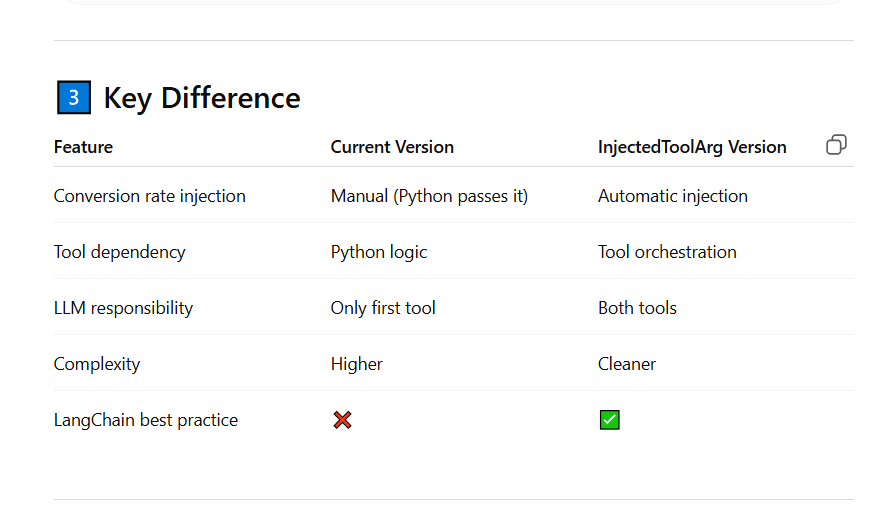